In [1]:
import numpy as np
import tensorflow as tf
import glob
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.manifold import trustworthiness
from scipy.spatial import distance_matrix

# ==========================================
# 1. 数据加载与预处理 (保留你的 CIR 截取逻辑)
# ==========================================
DATASET_PATTERN = "dichasus/dichasus-005*.tfrecords"

def load_dataset_integrated():
    files = glob.glob(DATASET_PATTERN)
    if not files: raise ValueError("未找到数据文件！")
    
    def parse(proto):
        desc = {
            "csi": tf.io.FixedLenFeature([], tf.string),
            "pos-lidar": tf.io.FixedLenFeature([], tf.string),
            "time": tf.io.FixedLenFeature([], tf.float32)
        }
        rec = tf.io.parse_single_example(proto, desc)
        csi = tf.io.parse_tensor(rec["csi"], out_type=tf.float32)
        csi = tf.ensure_shape(csi, (32, 1024, 2))
        csi = tf.complex(csi[:, :, 0], csi[:, :, 1])
        pos = tf.io.parse_tensor(rec["pos-lidar"], out_type=tf.float64)
        time = rec["time"]
        return csi, pos, time

    def preprocess(csi, pos, time):
        # 频域 -> 时域 -> 截取中心 32 taps (核心：锁定多径特征)
        csi = tf.signal.fftshift(csi, axes=1)
        csi_t = tf.signal.ifft(csi)
        csi_t = tf.signal.fftshift(csi_t, axes=1)
        csi_cut = csi_t[:, 512-16:512+16]
        return csi_cut, pos, time

    print("正在加载并预处理 CIR 数据...")
    ds = tf.data.TFRecordDataset(files).map(parse).map(preprocess)
    
    csi_list, pos_list, time_list = [], [], []
    for c, p, t in ds.as_numpy_iterator():
        csi_list.append(c)
        pos_list.append(p)
        time_list.append(t)
    return np.array(csi_list), np.array(pos_list), np.array(time_list)

2026-01-30 08:33:08.113732: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-30 08:33:08.179803: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-30 08:33:09.537027: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [4]:
import tensorflow as tf

def build_integrated_model(input_shape):
    inputs = tf.keras.Input(shape=input_shape, dtype=tf.complex64)
    
    # 1. 展平输入
    x = tf.keras.layers.Flatten()(inputs)
    
    # 2. 核心修复：使用 Lambda 层包装张量运算
    def physical_feature_extraction(ts):
        # 提取幅值
        mag = tf.math.abs(ts)
        # 提取相位角
        phase = tf.math.angle(ts)
        # 拼接幅值与相位的正余弦（分量化相位对轨迹平滑至关重要）
        return tf.concat([mag, tf.math.cos(phase), tf.math.sin(phase)], axis=-1)

    # 通过 Lambda 层调用
    x = tf.keras.layers.Lambda(physical_feature_extraction)(x)
    
    # 3. 骨干网络 (保持原有的 Swish + LayerNorm 逻辑)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(512)(x)
    
    # 定义残差块内部逻辑以防 Layer 对象重用冲突
    def apply_res_block(x_in, units):
        sc = tf.keras.layers.Dense(units)(x_in)
        # 路径 1
        x1 = tf.keras.layers.Dense(units)(x_in)
        x1 = tf.keras.layers.LayerNormalization()(x1)
        x1 = tf.keras.layers.Activation('swish')(x1)
        # 路径 2
        x1 = tf.keras.layers.Dense(units)(x1)
        x1 = tf.keras.layers.LayerNormalization()(x1)
        # 合并
        out = tf.keras.layers.Add()([sc, x1])
        return tf.keras.layers.Activation('swish')(out)

    x = apply_res_block(x, 512)
    x = apply_res_block(x, 256)
    
    x = tf.keras.layers.Dense(128, activation='swish')(x)
    outputs = tf.keras.layers.Dense(2, name='chart')(x)
    
    return tf.keras.Model(inputs=inputs, outputs=outputs)

# ==========================================
# 重新执行初始化
# ==========================================
# 确保 csi_data 的形状是 (N, 32, 32)
chart_model = build_integrated_model(csi_data.shape[1:])
print("模型构建成功！")


# ==========================================
# 3. 核心改进 Loss：自监督拓扑对齐
# ==========================================
def integrated_contrastive_loss(y_true, y_pred):
    dim = 2
    anchor = y_pred[:, 0:dim]
    positive = y_pred[:, dim:2*dim]
    negative = y_pred[:, 2*dim:3*dim]

    d_ap = tf.reduce_sum(tf.square(anchor - positive), axis=1)
    d_an = tf.reduce_sum(tf.square(anchor - negative), axis=1)

    # A. 结构保持项：使用 softplus 替代 hinge，提供全局平滑梯度
    loss_contrast = tf.reduce_mean(tf.math.softplus(d_ap - d_an + 1.0))

    # B. 局部平滑项 (继承你提供的 Smoothness 思想)
    loss_smooth = tf.reduce_mean(d_ap)

    # C. 全局散开正则：防止坍塌成线，优化 KS
    std_loss = tf.reduce_sum(tf.square(tf.math.reduce_std(anchor, axis=0) - 1.0))

    return loss_contrast + 0.3 * loss_smooth + 0.1 * std_loss



模型构建成功！


In [5]:
# ==========================================
# 4. 训练与对齐评估
# ==========================================
csi_data, pos_data, time_data = load_dataset_integrated()
chart_model = build_integrated_model(csi_data.shape[1:])

# 构建三路训练器
in_a = tf.keras.Input(shape=csi_data.shape[1:], dtype=tf.complex64)
in_p = tf.keras.Input(shape=csi_data.shape[1:], dtype=tf.complex64)
in_n = tf.keras.Input(shape=csi_data.shape[1:], dtype=tf.complex64)
trainer = tf.keras.Model(inputs=[in_a, in_p, in_n], 
                         outputs=tf.keras.layers.Concatenate(axis=1)([chart_model(in_a), chart_model(in_p), chart_model(in_n)]))

trainer.compile(optimizer=tf.keras.optimizers.Adam(5e-4), loss=integrated_contrastive_loss)

# 使用你提供的采样器框架，但增大负例窗口至 30s 以降低 KS
def adaptive_generator(csi, time, batch_size=256):
    n = len(csi)
    while True:
        a_idx = np.random.randint(0, n, batch_size)
        p_idx, n_idx = [], []
        for i in range(batch_size):
            t_a = time[a_idx[i]]
            # 正例 1s 内
            p_idx.append(np.random.choice(np.where(np.abs(time - t_a) < 1.0)[0]))
            # 负例 30s 外 (关键：更远的负例提供更好的全局拓扑)
            while True:
                cand = np.random.randint(0, n)
                if np.abs(time[cand] - t_a) > 30.0:
                    n_idx.append(cand); break
        yield (csi[a_idx], csi[p_idx], csi[n_idx]), np.zeros(batch_size)

# 执行训练
ds = tf.data.Dataset.from_generator(lambda: adaptive_generator(csi_data, time_data),
    output_signature=((tf.TensorSpec((None,32,32), tf.complex64),)*3, tf.TensorSpec((None,), tf.float32)))

trainer.fit(ds, steps_per_epoch=200, epochs=40, verbose=1)



正在加载并预处理 CIR 数据...


2026-01-30 08:57:12.314198: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 1/40


2026-01-30 08:57:16.704100: I external/local_xla/xla/service/service.cc:163] XLA service 0x74d03c01acc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-30 08:57:16.704138: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA L40S, Compute Capability 8.9
2026-01-30 08:57:16.704147: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (1): NVIDIA L40S, Compute Capability 8.9
2026-01-30 08:57:16.704154: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (2): NVIDIA L40S, Compute Capability 8.9
2026-01-30 08:57:16.704160: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (3): NVIDIA L40S, Compute Capability 8.9
2026-01-30 08:57:16.883802: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-30 08:57:17.856208: I external/local_xla/xla/st

  4/200 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 2.3267    

2026-01-30 08:57:33.811843: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'loop_abs_cosine_sine_fusion', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1769763453.872567  650225 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


200/200 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - loss: 0.7526
Epoch 2/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.2928
Epoch 3/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.2707
Epoch 4/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.2538
Epoch 5/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.2476
Epoch 6/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.2446
Epoch 7/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.2363
Epoch 8/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.2391
Epoch 9/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.2392
Epoch 10/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.2365
Epoch 11/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.2339
Epoch 12/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.2340
Epoch 13/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.2314
Epoch 14/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.2320
Epoch 15/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step

2026-01-30 09:00:48.943961: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-30 09:00:48.943999: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-30 09:00:48.944013: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-30 09:00:48.944025: I external/l

640/662 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

2026-01-30 09:00:53.190650: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 4 bytes spill stores, 4 bytes spill loads



662/662 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step

最终优化 KS: 0.5454


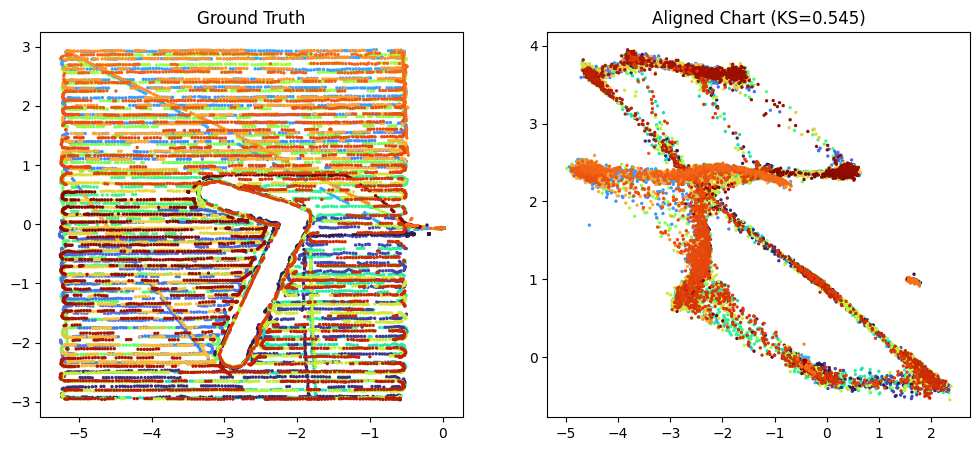

In [6]:
# 评估：Ridge 对齐并计算 KS
pred = chart_model.predict(csi_data.astype(np.complex64))
reg = Ridge(alpha=1.0).fit(pred[:1000], pos_data[:1000])
aligned = reg.predict(pred)

# 计算 KS Stress
idx = np.random.choice(len(pos_data), 1000, replace=False)
d_gt = distance_matrix(pos_data[idx], pos_data[idx])
d_pr = distance_matrix(aligned[idx], aligned[idx])
d_gt /= np.mean(d_gt); d_pr /= np.mean(d_pr)
ks = np.sqrt(np.sum((d_gt - d_pr)**2) / np.sum(d_gt**2))

print(f"\n最终优化 KS: {ks:.4f}")

# 可视化对比
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1); plt.scatter(pos_data[:,0], pos_data[:,1], c=time_data, s=2, cmap='turbo'); plt.title("Ground Truth")
plt.subplot(1,2,2); plt.scatter(aligned[:,0], aligned[:,1], c=time_data, s=2, cmap='turbo'); plt.title(f"Aligned Chart (KS={ks:.3f})")
plt.show()